# Unsupervised learning practice

- Objective: Explore some unsupervised learning algorithms in missiles dataset
## Question 1

1. Plot the curve PK with respect to DISTANCE for MACH_BLUE = 1.5, MACH_RED = 1.5, ALT_BLUE = 10, ALT_RED = 10, DELTA = 2. What do you notice?

In [35]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [36]:
## Load dataset

df =pd.read_csv("dataset_practical_session.csv")



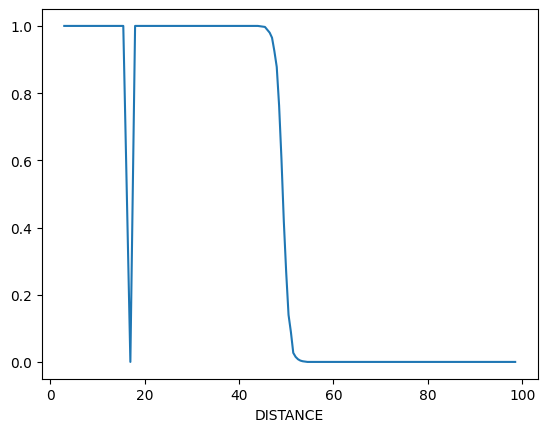

In [37]:
## Graph

df_ex = df[(df["MACH_BLUE"]==1.5) &
           (df["MACH_RED"]== 1.5) &
           (df["ALT_BLUE"] == 10) &
           (df["ALT_RED"]==10) &
           (df["DELTA"]==2)]

plt.xlabel("DISTANCE")
plt.plot(df_ex["DISTANCE"], df_ex["PK"])



## Question 2
Let’s find these outliers using unsupervised learning on X = [MACH_BLUE, MACH_RED, ALT_BLUE, ALT_RED, DISTANCE, DELTA, PK].

### 2.1 Isolation Forest
Test Isolation Forest. Is it better to perform it on X, or on X’ = [DISTANCE, PK] for each combination of MACH_BLUE, MACH_RED, ALT_BLUE, ALT_RED, and DELTA? How many outliers do you find?



#### 2.1.1 All dataset
- **32478 anomalies** contamination = 0.1
- **16239 anomalies** contamination = 0.05

In [38]:
## imports

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = StandardScaler()
df_sca = scaler.fit_transform(df)   

In [39]:
model=IsolationForest(n_estimators=50, max_samples='auto', contamination=float(0.1),max_features=1.0)
model.fit(df_sca)

IsolationForest(contamination=0.1, n_estimators=50)

In [40]:
labels = model.predict(df_sca)          # -1 outlier, 1 normal
scores = model.decision_function(df_sca)

In [41]:
df_anom=pd.DataFrame()
df_anom=df.copy()
df_anom["anomaly"] = labels
df_anom["scores"] = scores
df_anom.head(20)

,MACH_BLUE,MACH_RED,ALT_BLUE,ALT_RED,DELTA,DISTANCE,PK,anomaly,scores
0,0.5,0.5,0,0,0.0,1.0,1.000,-1,-0.046662
1,0.5,0.5,0,0,0.0,1.5,1.000,-1,-0.046662
2,0.5,0.5,0,0,0.0,2.0,1.000,-1,-0.046662
3,0.5,0.5,0,0,0.0,3.0,1.000,-1,-0.046662
4,0.5,0.5,0,0,0.0,3.5,1.000,-1,-0.046662
5,0.5,0.5,0,0,0.0,4.0,1.000,-1,-0.045818
6,0.5,0.5,0,0,0.0,5.0,1.000,-1,-0.045818
7,0.5,0.5,0,0,0.0,6.5,1.000,-1,-0.045818
8,0.5,0.5,0,0,0.0,7.0,1.000,-1,-0.046662
9,0.5,0.5,0,0,0.0,7.5,1.000,-1,-0.044975


In [42]:
anomaly=df_anom[df_anom['anomaly']==-1]
anomaly.describe()

,MACH_BLUE,MACH_RED,ALT_BLUE,ALT_RED,DELTA,DISTANCE,PK,anomaly,scores
count,32478.000000,32478.000000,32478.000000,32478.000000,32478.000000,32478.000000,32478.000000,32478.0,32478.000000
mean,1.214130,1.239501,17.934294,22.576513,1.354717,38.763301,0.612801,-1.0,-0.014586
std,0.661168,0.670629,16.747503,16.725136,1.255075,32.693455,0.435207,0.0,0.012769
min,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.0,-0.090716
25%,0.500000,0.500000,0.000000,0.000000,0.000000,10.000000,0.051000,-1.0,-0.020908
50%,1.000000,1.000000,10.000000,30.000000,1.000000,28.500000,0.898000,-1.0,-0.011100
75%,2.000000,2.000000,40.000000,40.000000,3.000000,67.000000,1.000000,-1.0,-0.004824
max,2.000000,2.000000,40.000000,40.000000,3.000000,100.000000,1.000000,-1.0,-0.000001


#### 2.1.2 Iteration

X’ = [DISTANCE, PK] for each combination of MACH_BLUE, MACH_RED, ALT_BLUE, ALT_RED, and DELTA? How many outliers do you find?

- **33451** contamination = 0.1
- **17334** contamination =0.5

In [43]:
def train_iforest(sub_df): ### We're going to use this fuction multiple times
    model = IsolationForest(
        n_estimators=50, 
        max_samples='auto', 
        contamination=0.05, 
        max_features=1.0,
        random_state=42
    )
    model.fit(sub_df[['DISTANCE', 'PK']])
    preds = model.predict(sub_df[['DISTANCE', 'PK']])
    return preds

In [46]:
results = []

# Iterar por todas las combinaciones únicas de las 5 variables
for x1 in set(df["MACH_BLUE"]):
    for x2 in set(df["MACH_RED"]):
        for x3 in set(df["ALT_BLUE"]):
            for x4 in set(df["ALT_RED"]):
                for x5 in set(df["DELTA"]):
                    
                    # Filtrar subset
                    sub_df = df[
                        (df["MACH_BLUE"] == x1) &
                        (df["MACH_RED"] == x2) &
                        (df["ALT_BLUE"] == x3) &
                        (df["ALT_RED"] == x4) &
                        (df["DELTA"] == x5)
                    ]
                    
                    if len(sub_df) > 20:  # evitar entrenar con muy pocos puntos
                        preds = train_iforest(sub_df)
                        n_anomalies = (preds == -1).sum()
                        
                        results.append({
                            "MACH_BLUE": x1,
                            "MACH_RED": x2,
                            "ALT_BLUE": x3,
                            "ALT_RED": x4,
                            "DELTA": x5,
                            "total_points": len(sub_df),
                            "anomalies": n_anomalies
                        })

# Convertir resultados a dataframe
df_results = pd.DataFrame(results)

In [ ]:
total_anomalies = df_results["anomalies"].sum()

print("Total de anomalías detectadas:", total_anomalies)
print("\nDesglose por combinación:")
print(df_results.head(20))

Total de anomalías detectadas: 17334

Desglose por combinación:
    MACH_BLUE  MACH_RED  ALT_BLUE  ALT_RED  DELTA  total_points  anomalies
0         0.5       0.5         0        0    0.0           116          6
1         0.5       0.5         0        0    0.5           117          6
2         0.5       0.5         0        0    2.0           121          6
3         0.5       0.5         0        0    1.0           117          6
4         0.5       0.5         0        0    1.5           116          6
5         0.5       0.5         0        0    2.5           122          7
6         0.5       0.5         0        0    3.0           119          6
7         0.5       0.5         0       40    0.0           106          6
8         0.5       0.5         0       40    0.5           121          6
9         0.5       0.5         0       40    2.0           115          6
10        0.5       0.5         0       40    1.0           108          6
11        0.5       0.5         0   

### 2.2 Local Outlier Factor
Test Local Outlier Factor. Is it better to perform it on X, or on X’ = [DISTANCE, PK] for each combination of MACH_BLUE, MACH_RED, ALT_BLUE, ALT_RED, and DELTA? How many outliers do you find?



In [ ]:
from sklearn.neighbors import LocalOutlierFactor


#### 2.2.1 All dataset
**32477 anomalies**

In [ ]:
clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)

In [ ]:
df_anom=pd.DataFrame()
df_anom=df.copy()
df_anom['anomaly']=clf.fit_predict(df)
df_anom['scores']=clf.negative_outlier_factor_
df_anom.head(20)

,MACH_BLUE,MACH_RED,ALT_BLUE,ALT_RED,DELTA,DISTANCE,PK,anomaly,scores
0,0.5,0.5,0,0,0.0,1.0,1.000,-1,-1.103802
1,0.5,0.5,0,0,0.0,1.5,1.000,-1,-1.070823
2,0.5,0.5,0,0,0.0,2.0,1.000,-1,-1.064330
3,0.5,0.5,0,0,0.0,3.0,1.000,1,-1.026739
4,0.5,0.5,0,0,0.0,3.5,1.000,-1,-1.057280
5,0.5,0.5,0,0,0.0,4.0,1.000,-1,-1.059866
6,0.5,0.5,0,0,0.0,5.0,1.000,-1,-1.124130
7,0.5,0.5,0,0,0.0,6.5,1.000,-1,-1.091636
8,0.5,0.5,0,0,0.0,7.0,1.000,-1,-1.108923
9,0.5,0.5,0,0,0.0,7.5,1.000,-1,-1.086503


In [ ]:
anomaly=df_anom[df_anom['anomaly']==-1]
anomaly.describe()

,MACH_BLUE,MACH_RED,ALT_BLUE,ALT_RED,DELTA,DISTANCE,PK,anomaly,scores
count,32477.000000,32477.000000,32477.000000,32477.000000,32477.000000,32477.000000,32477.000000,32477.0,3.247700e+04
mean,1.172722,1.196000,20.922499,21.040121,1.430243,46.288019,0.528581,-1.0,-1.414869e-02
std,0.650314,0.647104,17.361847,16.768848,1.297579,32.746400,0.440030,0.0,1.197840e-02
min,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.0,-8.777496e-02
25%,0.500000,0.500000,0.000000,0.000000,0.000000,16.500000,0.000000,-1.0,-2.041150e-02
50%,1.000000,1.000000,20.000000,20.000000,1.000000,41.000000,0.602000,-1.0,-1.100399e-02
75%,2.000000,2.000000,40.000000,40.000000,3.000000,77.000000,1.000000,-1.0,-4.829769e-03
max,2.000000,2.000000,40.000000,40.000000,3.000000,100.000000,1.000000,-1.0,-7.833531e-08


#### 2.2.2 Iteration

**33436**

In [ ]:
def train_LocalOut(sub_df): ### We're going to use this fuction multiple times
    clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
    preds = clf.fit_predict(sub_df[['DISTANCE', 'PK']])
    return preds

In [ ]:
results = []

# Iterar por todas las combinaciones únicas de las 5 variables
for x1 in set(df["MACH_BLUE"]):
    for x2 in set(df["MACH_RED"]):
        for x3 in set(df["ALT_BLUE"]):
            for x4 in set(df["ALT_RED"]):
                for x5 in set(df["DELTA"]):
                    
                    # Filtrar subset
                    sub_df = df[
                        (df["MACH_BLUE"] == x1) &
                        (df["MACH_RED"] == x2) &
                        (df["ALT_BLUE"] == x3) &
                        (df["ALT_RED"] == x4) &
                        (df["DELTA"] == x5)
                    ]
                    
                    if len(sub_df) > 20:  # evitar entrenar con muy pocos puntos
                        preds = train_LocalOut(sub_df)
                        n_anomalies = (preds == -1).sum()
                        
                        results.append({
                            "MACH_BLUE": x1,
                            "MACH_RED": x2,
                            "ALT_BLUE": x3,
                            "ALT_RED": x4,
                            "DELTA": x5,
                            "total_points": len(sub_df),
                            "anomalies": n_anomalies
                        })

# Convertir resultados a dataframe
df_results = pd.DataFrame(results)

In [ ]:
total_anomalies = df_results["anomalies"].sum()

print("Total de anomalías detectadas:", total_anomalies)
print("\nDesglose por combinación:")
print(df_results.head(20))

Total de anomalías detectadas: 33436

Desglose por combinación:
    MACH_BLUE  MACH_RED  ALT_BLUE  ALT_RED  DELTA  total_points  anomalies
0         0.5       0.5         0        0    0.0           116         12
1         0.5       0.5         0        0    0.5           117         12
2         0.5       0.5         0        0    2.0           121         12
3         0.5       0.5         0        0    1.0           117         12
4         0.5       0.5         0        0    1.5           116         12
5         0.5       0.5         0        0    2.5           122         13
6         0.5       0.5         0        0    3.0           119         12
7         0.5       0.5         0       40    0.0           106         11
8         0.5       0.5         0       40    0.5           121         12
9         0.5       0.5         0       40    2.0           115         12
10        0.5       0.5         0       40    1.0           108         11
11        0.5       0.5         0   

### 2.3 DBSCAN

Test DBSCAN. Is it better to perform it on X, or on X’ = [DISTANCE, PK] for each combination of MACH_BLUE, MACH_RED, ALT_BLUE, ALT_RED, and DELTA? How many outliers do you find?

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


#### 2.3.1 All Dataset

**1947.0 Anomalies**

In [ ]:
X = df.values
X_scaled = StandardScaler().fit_transform(X)

model = DBSCAN(eps=0.5, min_samples=5)

In [ ]:
df_anom=pd.DataFrame()
df_anom=df.copy()
df_anom['anomaly']=model.fit_predict(X_scaled)
df_anom.head(20)

,MACH_BLUE,MACH_RED,ALT_BLUE,ALT_RED,DELTA,DISTANCE,PK,anomaly
0,0.5,0.5,0,0,0.0,1.0,1.000,0
1,0.5,0.5,0,0,0.0,1.5,1.000,0
2,0.5,0.5,0,0,0.0,2.0,1.000,0
3,0.5,0.5,0,0,0.0,3.0,1.000,0
4,0.5,0.5,0,0,0.0,3.5,1.000,0
5,0.5,0.5,0,0,0.0,4.0,1.000,0
6,0.5,0.5,0,0,0.0,5.0,1.000,0
7,0.5,0.5,0,0,0.0,6.5,1.000,0
8,0.5,0.5,0,0,0.0,7.0,1.000,0
9,0.5,0.5,0,0,0.0,7.5,1.000,0


In [ ]:
anomaly=df_anom[df_anom['anomaly']==-1]
anomaly.describe()

,MACH_BLUE,MACH_RED,ALT_BLUE,ALT_RED,DELTA,DISTANCE,PK,anomaly
count,1947.000000,1947.000000,1947.000000,1947.000000,1947.000000,1947.000000,1947.000000,1947.0
mean,1.284540,1.220596,20.267078,19.625064,1.625321,37.841294,0.373593,-1.0
std,0.563248,0.560797,14.302220,14.280020,1.004850,22.035883,0.220422,0.0
min,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.0
25%,1.000000,0.500000,10.000000,10.000000,1.000000,21.000000,0.000000,-1.0
50%,1.500000,1.000000,20.000000,20.000000,1.500000,35.000000,0.484000,-1.0
75%,2.000000,1.500000,30.000000,30.000000,2.500000,52.250000,0.516000,-1.0
max,2.000000,2.000000,40.000000,40.000000,3.000000,100.000000,0.932000,-1.0


#### 2.3.2 iteration

**3108 anomalies**

In [ ]:
def detect_dbscan(sub_df, eps=0.5, min_samples=5):
    # Escalar datos (DBSCAN es sensible a escala)
    X = sub_df[['DISTANCE', 'PK']].values
    X_scaled = StandardScaler().fit_transform(X)
    
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X_scaled)
    
    # Anomalías = label -1
    anomalies = sub_df[labels == -1].copy()
    anomalies["dbscan_label"] = -1
    
    # Como DBSCAN no tiene score, calculamos distancia promedio al cluster más cercano
    core_samples = model.components_
    if len(core_samples) > 0 and len(anomalies) > 0:
        # Calcular distancia mínima de cada anomalía a puntos núcleo
        dists = np.linalg.norm(
            anomalies[['DISTANCE','PK']].values[:, None] - core_samples, axis=2
        )
        anomalies["anomaly_score"] = dists.min(axis=1)
    else:
        anomalies["anomaly_score"] = np.nan
    
    return anomalies

In [ ]:
anomaly_rows = []

# Iterar por todas las combinaciones
for x1 in set(df["MACH_BLUE"]):
    for x2 in set(df["MACH_RED"]):
        for x3 in set(df["ALT_BLUE"]):
            for x4 in set(df["ALT_RED"]):
                for x5 in set(df["DELTA"]):
                    
                    # Subset
                    sub_df = df[
                        (df["MACH_BLUE"] == x1) &
                        (df["MACH_RED"] == x2) &
                        (df["ALT_BLUE"] == x3) &
                        (df["ALT_RED"] == x4) &
                        (df["DELTA"] == x5)
                    ]
                    
                    if len(sub_df) > 5:  # DBSCAN necesita puntos suficientes
                        anomalies = detect_dbscan(sub_df, eps=0.5, min_samples=5)
                        if len(anomalies) > 0:
                            anomalies["MACH_BLUE"] = x1
                            anomalies["MACH_RED"] = x2
                            anomalies["ALT_BLUE"] = x3
                            anomalies["ALT_RED"] = x4
                            anomalies["DELTA"] = x5
                            anomaly_rows.append(anomalies)
                    
                    

df_anomalies = pd.concat(anomaly_rows, ignore_index=True)

In [ ]:
total_anomalies = len(df_anomalies)

print("Total de anomalías detectadas con DBSCAN:", total_anomalies)
print("\nEjemplo de anomalías detectadas:")
print(df_anomalies.head(20))

Total de anomalías detectadas con DBSCAN: 3108

Ejemplo de anomalías detectadas:
    MACH_BLUE  MACH_RED  ALT_BLUE  ALT_RED  DELTA  DISTANCE     PK  \
0         0.5       0.5         0        0    0.0      16.0  0.455   
1         0.5       0.5         0        0    0.5      18.0  0.523   
2         0.5       0.5         0        0    2.0      40.0  0.489   
3         0.5       0.5         0        0    1.0      23.0  0.424   
4         0.5       0.5         0        0    1.5      30.0  0.525   
5         0.5       0.5         0        0    3.0      67.5  0.458   
6         0.5       0.5         0       40    0.0      12.5  0.582   
7         0.5       0.5         0       40    0.0      13.0  0.401   
8         0.5       0.5         0       40    0.5      14.5  0.638   
9         0.5       0.5         0       40    0.5      15.0  0.434   
10        0.5       0.5         0       40    2.0      36.5  0.421   
11        0.5       0.5         0       40    1.0      19.5  0.492   
12       

In [ ]:
import matplotlib.pyplot as plt

def plot_anomalies(sub_df, anomalies, title=""):
    plt.figure(figsize=(8,6))
    
    # Puntos normales
    normal_points = sub_df[~sub_df.index.isin(anomalies.index)]
    plt.scatter(normal_points["DISTANCE"], normal_points["PK"], 
                c="blue", label="Normal", alpha=0.6)
    
    # Puntos anómalos
    plt.scatter(anomalies["DISTANCE"], anomalies["PK"], 
                c="red", label="Anomaly", marker="x", s=100)
    
    plt.xlabel("Distance")
    plt.ylabel("PK")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

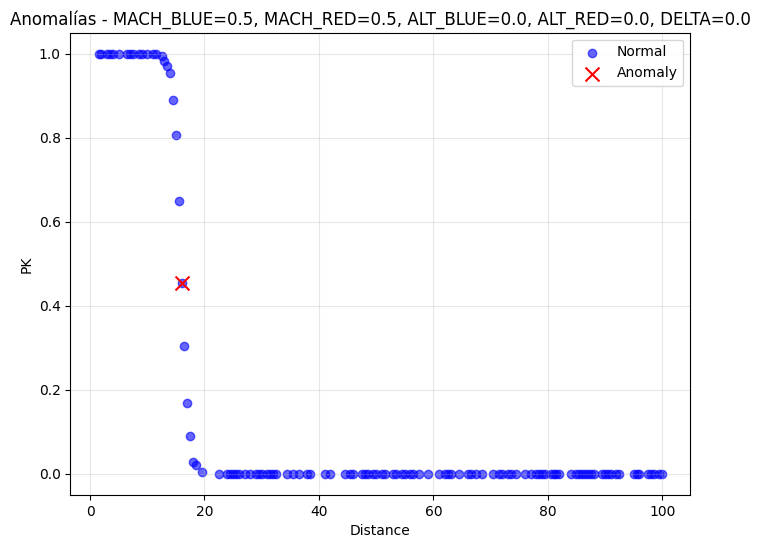

In [ ]:
if not df_anomalies.empty:
    # Elegir la primera combinación
    row = df_anomalies.iloc[0]
    sub_df = df[
        (df["MACH_BLUE"] == row["MACH_BLUE"]) &
        (df["MACH_RED"] == row["MACH_RED"]) &
        (df["ALT_BLUE"] == row["ALT_BLUE"]) &
        (df["ALT_RED"] == row["ALT_RED"]) &
        (df["DELTA"] == row["DELTA"])
    ]
    
    # Filtrar anomalías de esa combinación
    sub_anomalies = df_anomalies[
        (df_anomalies["MACH_BLUE"] == row["MACH_BLUE"]) &
        (df_anomalies["MACH_RED"] == row["MACH_RED"]) &
        (df_anomalies["ALT_BLUE"] == row["ALT_BLUE"]) &
        (df_anomalies["ALT_RED"] == row["ALT_RED"]) &
        (df_anomalies["DELTA"] == row["DELTA"])
    ]
    
    # Graficar
    title = f"Anomalías - MACH_BLUE={row['MACH_BLUE']}, MACH_RED={row['MACH_RED']}, ALT_BLUE={row['ALT_BLUE']}, ALT_RED={row['ALT_RED']}, DELTA={row['DELTA']}"
    plot_anomalies(sub_df, sub_anomalies, title=title)